# ***US Visa Approval Analysis***

## Business Problem

The Office of Foreign Labor Certification processes thousands of visa applications each year. With increasing applications, it is important to understand what factors influence visa approval or denial.

This analysis explores visa application data to identify trends and key drivers that affect visa certification.

## Project Objectives

• Analyze the distribution of visa approvals and denials  
• Identify factors influencing visa certification  
• Explore relationships between wages, education, experience, and approval status  
• Generate insights to help employers improve visa approval chances

## Dataset Description

The dataset contains attributes related to employees and employers applying for US work visas.

Key Features:
- education_of_employee
- continent
- has_job_experience
- prevailing_wage
- full_time_position
- region_of_employment
- case_status (Visa Certified or Denied)

In [1]:
# Installing the libraries with the specified version.
!pip install numpy pandas scikit-learn matplotlib seaborn xgboost -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
df= pd.read_csv("/content/drive/MyDrive/Python Course/Project 3-Advanced Machine Learning/EasyVisa.csv")

In [5]:
df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
df.shape

(25480, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


#Exploratory Data Analysis

Let's check the statistical summary of the data

In [8]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


Fixing the negative values in number of employees columns

In [9]:
df = df[df['no_of_employees'] >= 0]

In [10]:
median_val = df[df['no_of_employees'] > 0]['no_of_employees'].median()
df.loc[df['no_of_employees'] < 0, 'no_of_employees'] = median_val

Let's check the count of each unique category in each of the categorical variables

In [11]:
# Select only categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Loop through each categorical column and print value counts
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: case_id
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
EZYV08       1
Name: count, Length: 25447, dtype: int64

Column: continent
continent
Asia             16840
Europe            3727
North America     3287
South America      851
Africa             550
Oceania            192
Name: count, dtype: int64

Column: education_of_employee
education_of_employee
Bachelor's     10220
Master's        9622
High School     3416
Doctorate       2189
Name: count, dtype: int64

Column: has_job_experience
has_job_experience
Y    14786
N    10661
Name: count, dtype: int64

Column: requires_job_training
requires_job_training
N    22498
Y     2949
Name: count, dtype: int64

Column: region_of_employment
region_of_employment
Northeast    7189
South        7006
West         6578
Midwest      4299
Island        375
Name: count, dtype: int64

Column: unit_of_wage
unit_of_wage
Year     22933


Univariate Analysis

In [37]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# def histogram_boxplot(data, feature, figsize=(15,10), kde=False, bins=None):

#     f2, (ax_box2, ax_hist2) = plt.subplots(
#         nrows=2,
#         sharex=True,
#         gridspec_kw={"height_ratios": (0.25, 0.75)},
#         figsize=figsize
#     )

#     sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")

#     sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins)

#     ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")
#     ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")

#     histogram_boxplot(df, "prevailing_wage", kde=True)
#     plt.show()

In [39]:
# function to create labeled barplots


# def labeled_barplot(data, feature, perc=False, n=None):
#     """
#     Barplot with percentage at the top

#     data: dataframe
#     feature: dataframe column
#     perc: whether to display percentages instead of count (default is False)
#     n: displays the top n category levels (default is None, i.e., display all levels)
#     """

#     total = len(data[feature])  # length of the column
#     count = data[feature].nunique()
#     if n is None:
#         plt.figure(figsize=(count + 1, 5))
#     else:
#         plt.figure(figsize=(n + 1, 5))

#     plt.xticks(rotation=90, fontsize=15)
#     ax = sns.countplot(
#         data=data,
#         x=feature,
#         palette="Paired",
#         order=data[feature].value_counts().index[:n].sort_values(),
#     )

#     for p in ax.patches:
#         if perc == True:
#             label = "{:.1f}%".format(
#                 100 * p.get_height() / total
#             )  # percentage of each class of the category
#         else:
#             label = p.get_height()  # count of each level of the category

#         x = p.get_x() + p.get_width() / 2  # width of the plot
#         y = p.get_height()  # height of the plot

#         ax.annotate(
#             label,
#             (x, y),
#             ha="center",
#             va="center",
#             size=12,
#             xytext=(0, 5),
#             textcoords="offset points",
#         )  # annotate the percentage

#     plt.show()  # show the plot

Observations on education of employee

In [40]:
print(df['education_of_employee'].value_counts(dropna=False))

education_of_employee
Bachelor's     10220
Master's        9622
High School     3416
Doctorate       2189
Name: count, dtype: int64


Most applicants hold a Bachelor's degree. However, Master's degree holders show a higher proportion of visa certifications compared to other education levels.

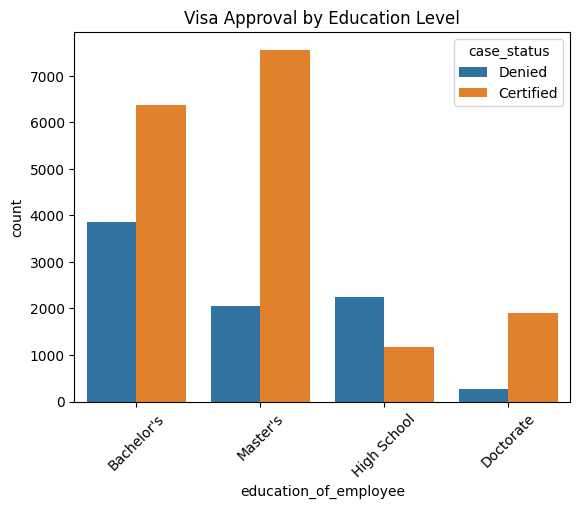

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x='education_of_employee', hue='case_status', order=df['education_of_employee'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visa Approval by Education Level")
plt.show()

For Master's education there are more chances of Visa Certification.

Observations on region of employment

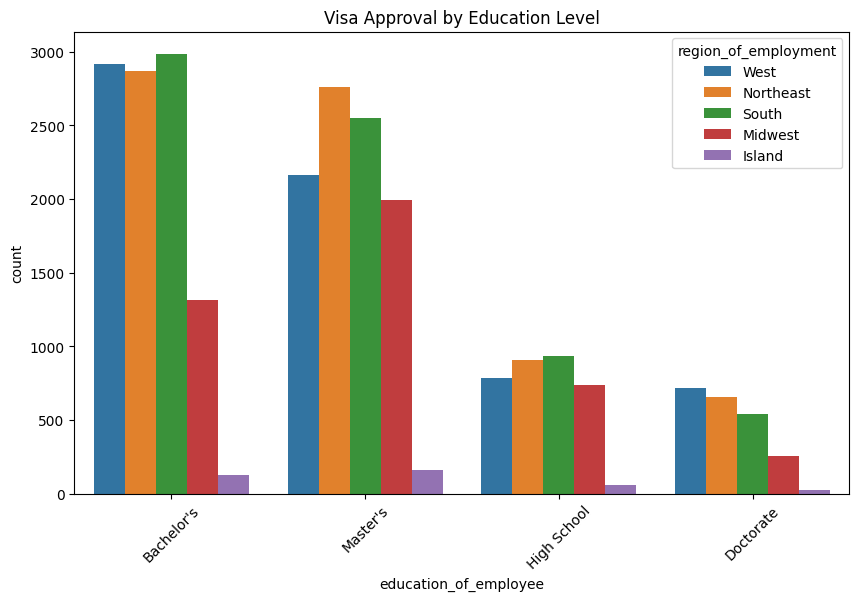

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='education_of_employee', hue='region_of_employment', order=df['education_of_employee'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visa Approval by Education Level")
plt.show()

Observations on job experience

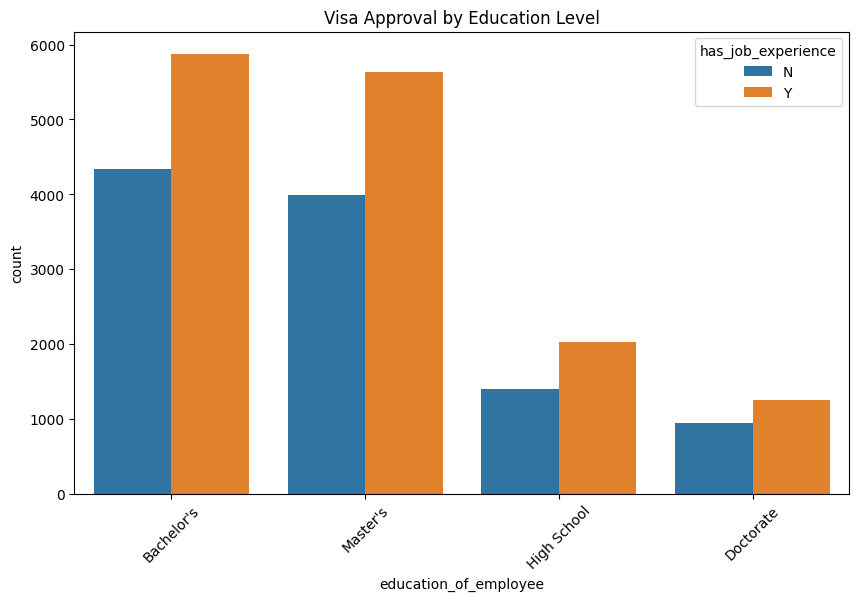

In [64]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='education_of_employee', hue='has_job_experience', order=df['education_of_employee'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visa Approval by Education Level")
plt.show()

Observations on case status

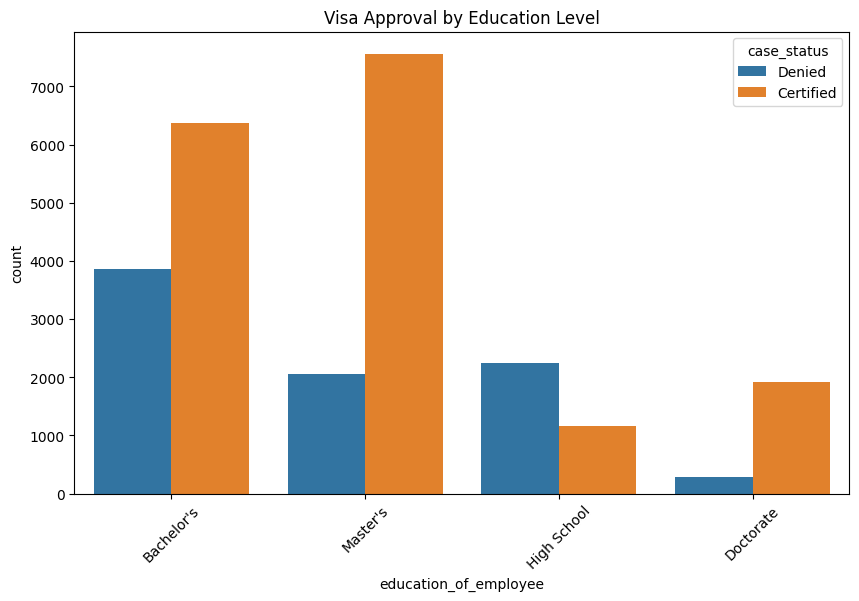

In [44]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='education_of_employee', hue='case_status', order=df['education_of_employee'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visa Approval by Education Level")
plt.show()

Bivariate Analysis

Creating functions that will help us with further analysis.

In [63]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [62]:
# def stacked_barplot(data, predictor, target):
#     """
#     Print the category counts and plot a stacked bar chart

#     data: dataframe
#     predictor: independent variable
#     target: target variable
#     """
#     count = data[predictor].nunique()
#     sorter = data[target].value_counts().index[-1]
#     tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
#         by=sorter, ascending=False
#     )
#     print(tab1)
#     print("-" * 120)
#     tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
#         by=sorter, ascending=False
#     )
#     tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
#     plt.legend(
#         loc="lower left", frameon=False,
#     )
#     plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
#     plt.show()

Does higher education increase the chances of visa certification for well-paid jobs abroad?

In [65]:
# Approval rate by education
edu_approval_rate = df[df['case_status'] == 'Certified']['education_of_employee'].value_counts() / df['education_of_employee'].value_counts()
print(edu_approval_rate.sort_values(ascending=False))

education_of_employee
Doctorate      0.872545
Master's       0.786219
Bachelor's     0.622505
High School    0.340749
Name: count, dtype: float64


**Yes,Higher Education increase the chances of visa certification for well-paid Jobs.**

How does visa status vary across different continents?

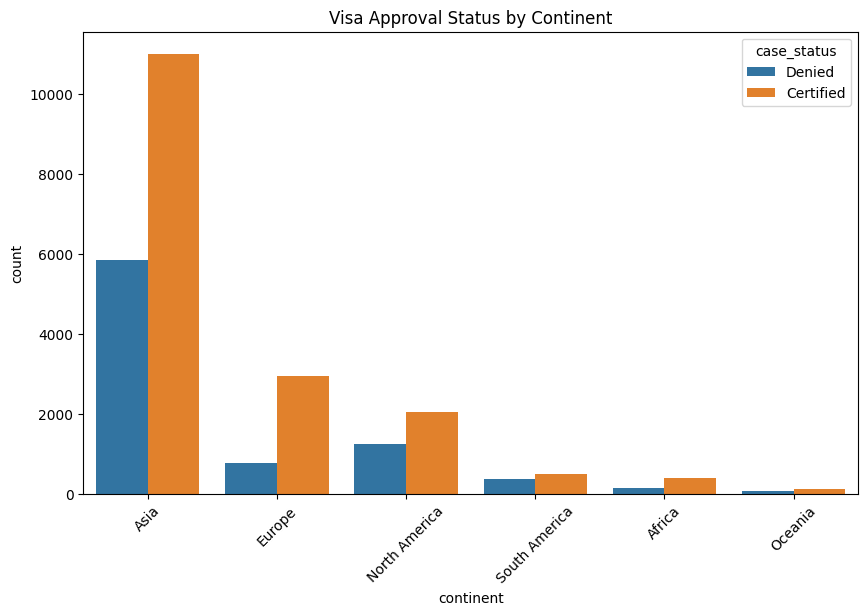

In [66]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='continent', hue='case_status', order=df['continent'].value_counts().index)
plt.title('Visa Approval Status by Continent')
plt.xticks(rotation=45)
plt.show()

Asia has most successful visa certified.

Does having prior work experience influence the chances of visa certification for career opportunities abroad?

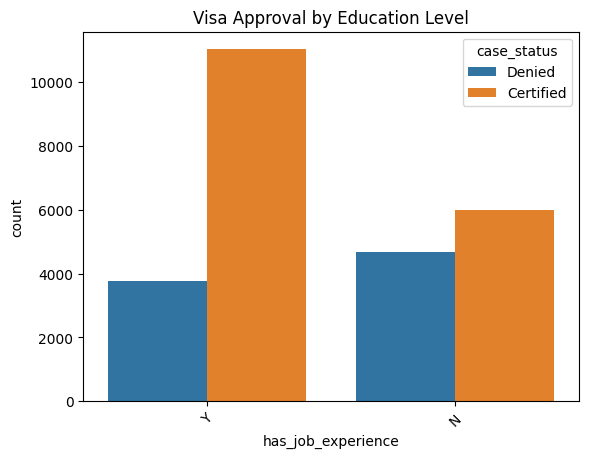

In [67]:
sns.countplot(data=df, x='has_job_experience', hue='case_status', order=df['has_job_experience'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visa Approval by Education Level")
plt.show()

People who has job experience are more likely to get visa certified.

Is the prevailing wage consistent across all regions of the US?

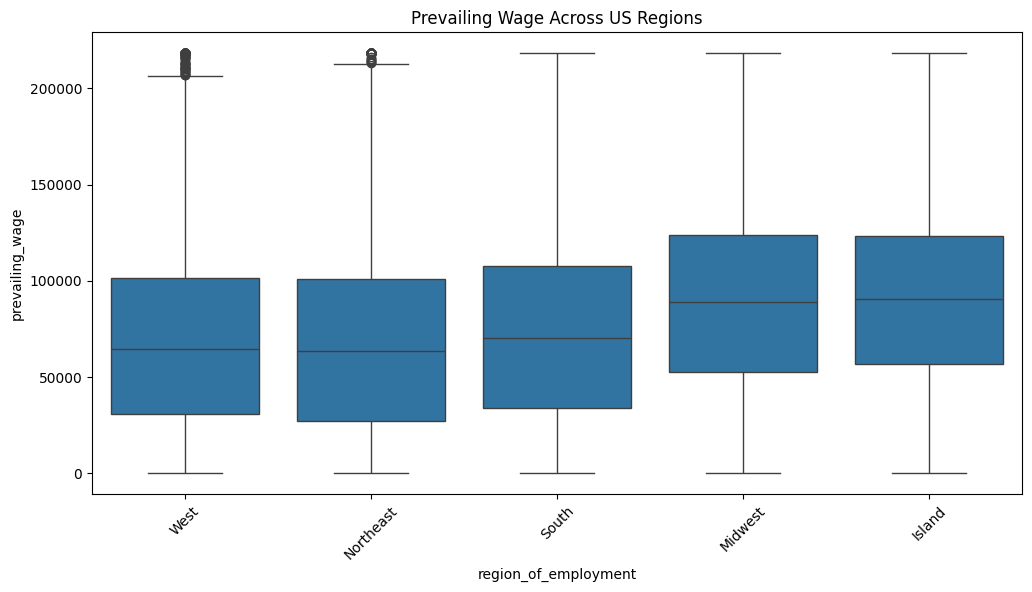

In [51]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='region_of_employment', y='prevailing_wage')
plt.xticks(rotation=45)
plt.title('Prevailing Wage Across US Regions')
plt.show()

Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

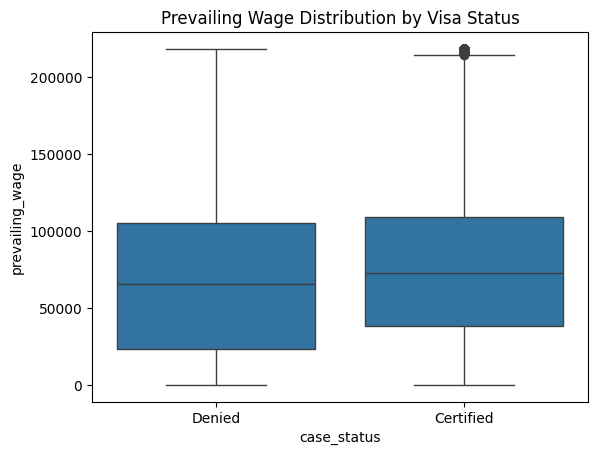

In [52]:
sns.boxplot(data=df, x='case_status', y='prevailing_wage')
plt.title("Prevailing Wage Distribution by Visa Status")
plt.show()

Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?


<Axes: xlabel='unit_of_wage', ylabel='count'>

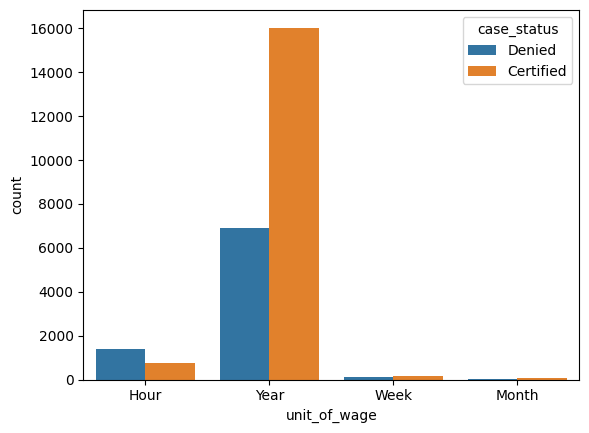

In [53]:
sns.countplot(data=df, x='unit_of_wage', hue='case_status')

**Data Pre-processing**

Outlier Check

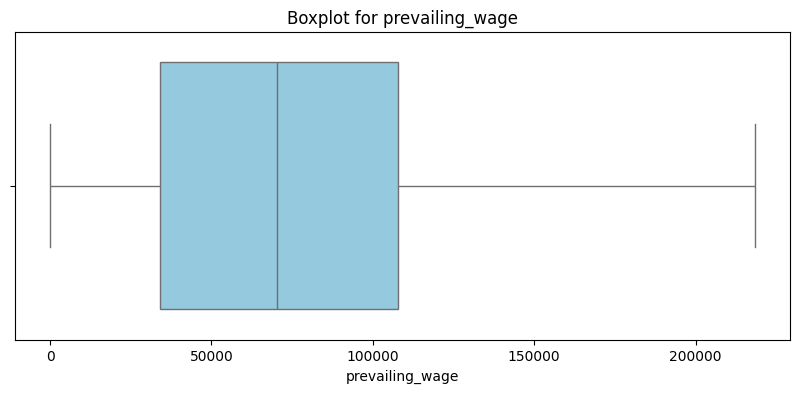

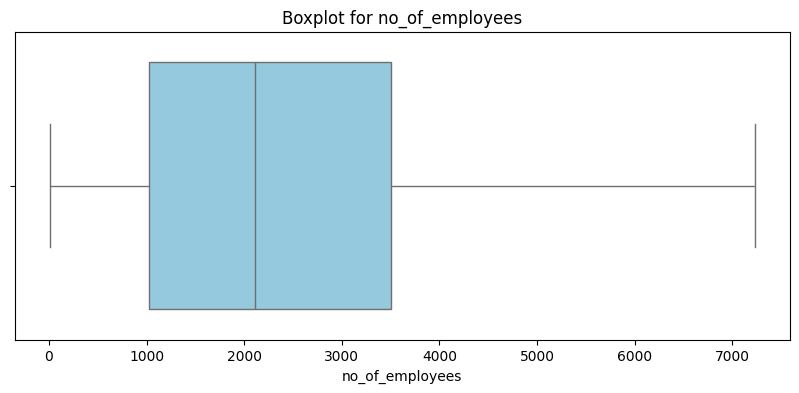

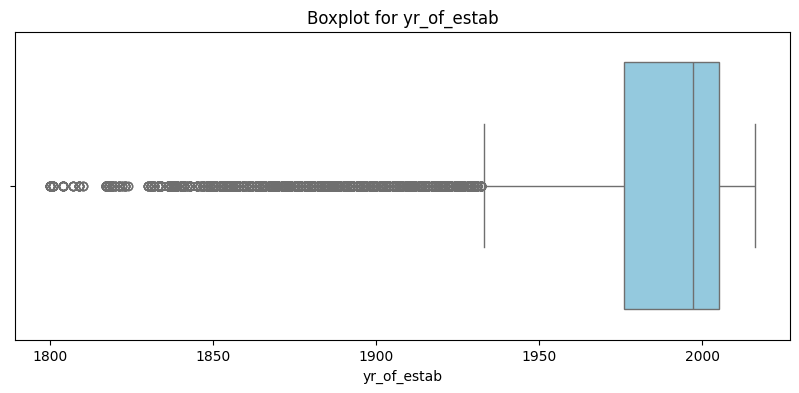

In [54]:
# Visual Outlier
numeric_cols = ['prevailing_wage', 'no_of_employees', 'yr_of_estab']

import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot for {col}')
    plt.show()

In [58]:
def cap_outliers_fixed(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - 1.5 * IQR)  # Ensure no negative values
    upper = Q3 + 1.5 * IQR
    data[column] = np.where(data[column] < lower, lower, data[column])
    data[column] = np.where(data[column] > upper, upper, data[column])
    print(f"{column} capped to [{lower:.2f}, {upper:.2f}]")

In [59]:
df['company_age'] = 2025 - df['yr_of_estab']

# Apply fixed capping
for col in ['prevailing_wage', 'no_of_employees', 'company_age']:
    cap_outliers_fixed(df, col)

prevailing_wage capped to [0.00, 218289.95]
no_of_employees capped to [0.00, 7228.75]
company_age capped to [0.00, 92.50]


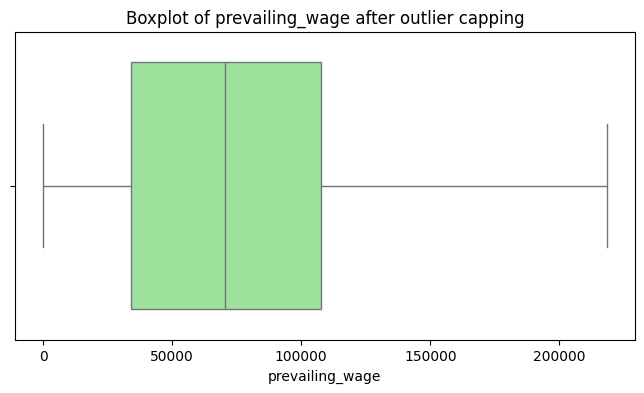

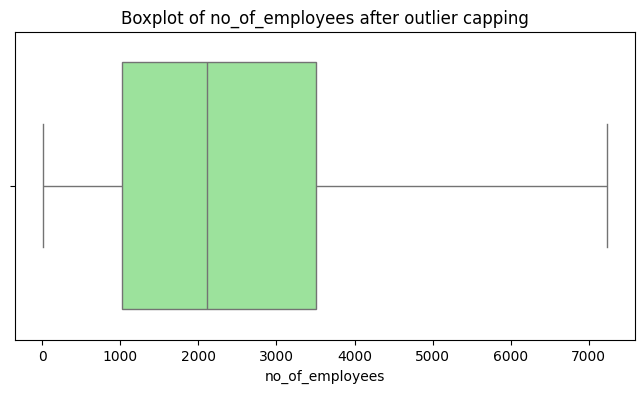

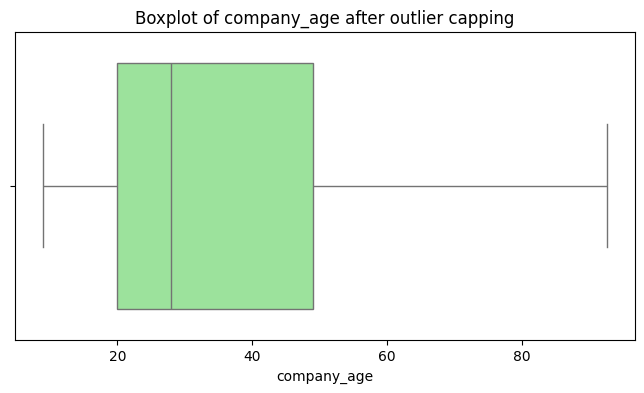

In [61]:
for col in ['prevailing_wage', 'no_of_employees', 'company_age']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col} after outlier capping')
    plt.show()

## Key Insights

• Applicants with higher prevailing wages tend to have higher visa certification rates.

• Candidates with prior job experience have better chances of visa approval.

• Full-time job positions are certified more frequently than part-time positions.

• Certain regions show higher visa approval trends.

## Business Recommendations

• Employers should offer competitive wages to improve visa approval chances.

• Hiring candidates with prior work experience may increase certification probability.

• Full-time job positions appear to have higher approval success.

## Conclusion

This analysis highlights the key factors associated with US visa certification. Wage levels, job experience, and employment type appear to influence approval outcomes. These insights can help employers better understand visa application trends and improve hiring strategies.